In [3]:
from compute_auc import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, ScalarFormatter

mpl.rcParams['text.usetex'] = False
if 'text.latex.preamble' in mpl.rcParams:
    mpl.rcParams['text.latex.preamble'] = ''
plt.rcParams["font.size"] = 14


def get_reward_curve(tensorboard_log_dir):
    # Initialize an EventAccumulator and load the event file (TensorBoard log file)
    event_acc = EventAccumulator(tensorboard_log_dir)
    event_acc.Reload()

    # Get the reward data
    reward_data = event_acc.Scalars("rollout/ep_rew_mean")

    # Extract the step numbers and corresponding rewards
    _steps = [entry.step for entry in reward_data]
    _rewards = [entry.value for entry in reward_data]
    
    # normalize and numpify the steps and rewards
    steps = np.array(_steps)
    rewards = np.array(_rewards)
    
    return steps, rewards


def get_data(tensorboard_logs_path, prefix="./logs/ppo/", default_length=98):
    # Use the function to find all files with 'events.out.tfevents' in their names
    event_folders = find_folders(prefix, tensorboard_logs_path)
    event_files = []
    for folder in event_folders:
        event_files.extend(
            find_files(prefix + folder + "/", "*events.out.tfevents*")
        )
    
    data = []

    for filename in event_files:
        try:
            _steps, _rewards = get_reward_curve(filename)
            data.append(
                {
                    "filename": filename,
                    "steps": _steps,
                    "rewards": _rewards
                }
            )
        except:
            continue

    return data


def process_data(data, default_length=98):
    _data = []
    for d in data:
        if d["rewards"].shape[0] == default_length:
            _data.append(d)

    return _data


def plot_subplot(data, axs, i, offset=None):
    
    formatter = ScalarFormatter(useMathText=True)    
    data_list = data
    
    # Normalize input to a list of dicts
    if isinstance(data, dict):
        data_list = [data]
    elif not isinstance(data,list):
        data_list = list(data)   

    if offset is not None:
        data_list = data_list[:offset]
    
    # Plot each run in the list
    for d in data_list:
        steps = d.get("steps")
        rewards = d.get("rewards")

        if steps is None or rewards is None:
            continue
        axs[i].plot(steps, rewards, alpha=0.65, linewidth=2)

    axs[i].set_xlim([0, 9e5])
    axs[i].set_ylim([-2.0, 1.0])
    axs[i].ticklabel_format(style='sci',scilimits=(-3,4),axis='both')
    axs[i].xaxis.major.formatter._useMathText = True

    axs[i].xaxis.set_major_locator(MultipleLocator(5e4))
    axs[i].xaxis.set_minor_locator(MultipleLocator(5e4/4))
    axs[i].yaxis.set_major_locator(MultipleLocator(0.25))
    axs[i].yaxis.set_minor_locator(MultipleLocator(0.25/4))

    axs[i].grid(True, "minor", color="0.85", linewidth=0.50, zorder=-20)
    axs[i].grid(True, "major", color="0.65", linewidth=0.75, zorder=-10)
    axs[i].tick_params(which="both", bottom=False, left=False)


# def main():

# 	num_objects = 4
# 	dist_type = "BASIC_SKILLS"
# 	algo = "trans"
# 	SEED = 60

# 	name_list = [
# 		f"{algo}_{num_objects}_8_FULL_60",
# 		f"{algo}_{num_objects}_8_{dist_type}_60",
# 		f"{algo}_{num_objects}_8_{dist_type}_EXCL_60",
# 		# f"{algo}_{num_objects}_8_FULL_{SEED}",
# 		# f"{algo}_{num_objects}_8_{dist_type}_{SEED}",
# 		# f"{algo}_{num_objects}_8_{dist_type}_EXCL_{SEED}",
# 		# f"trans_{num_objects}_8_FULL",
# 	]

# 	fig, axs = plt.subplots(1, 3, figsize=(24, 8))
# 	# axs = axs.reshape(-1)

# 	for i, name in enumerate(name_list):
# 		try:
# 			_data = get_data(f"minigrid_{name}_tensorboard", prefix="./logs/ppo/")
# 			# _data = process_data(_data, default_length=98)
# 			plot_subplot(_data, axs, i)
# 		except:
# 			continue
		
# 		axs[i].set_title(name.capitalize() + " Based Agent")
# 		axs[i].set_xlabel("Timesteps")
# 		axs[i].set_ylabel("Rewards")
		
# 	# axs[-1].axis("off")

# 	plt.subplots_adjust(wspace=0.25, hspace=0.3)
# 	plt.savefig(f"images/learning_curves_trans_{num_objects}_8_{SEED}.png", dpi=200, transparent=False, bbox_inches="tight")
# 	plt.show()

if __name__ == "__main__":
	# main()
	...

In [4]:
TRAINING_DATA_STATS = list()
labels = ["Transformer","MLP"]

Processing Distribution Type: FULL with Distractors: 0, and logdirs: ['logs/ppo/simple/minigrid_trans_0_8_FULL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_FULL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_FULL_60_tensorboard', 'logs/ppo/minigrid_mlp_0_8_FULL_42_tensorboard', 'logs/ppo/minigrid_mlp_0_8_FULL_51_tensorboard', 'logs/ppo/minigrid_mlp_0_8_FULL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Full_0_6_Learning_Curve.png


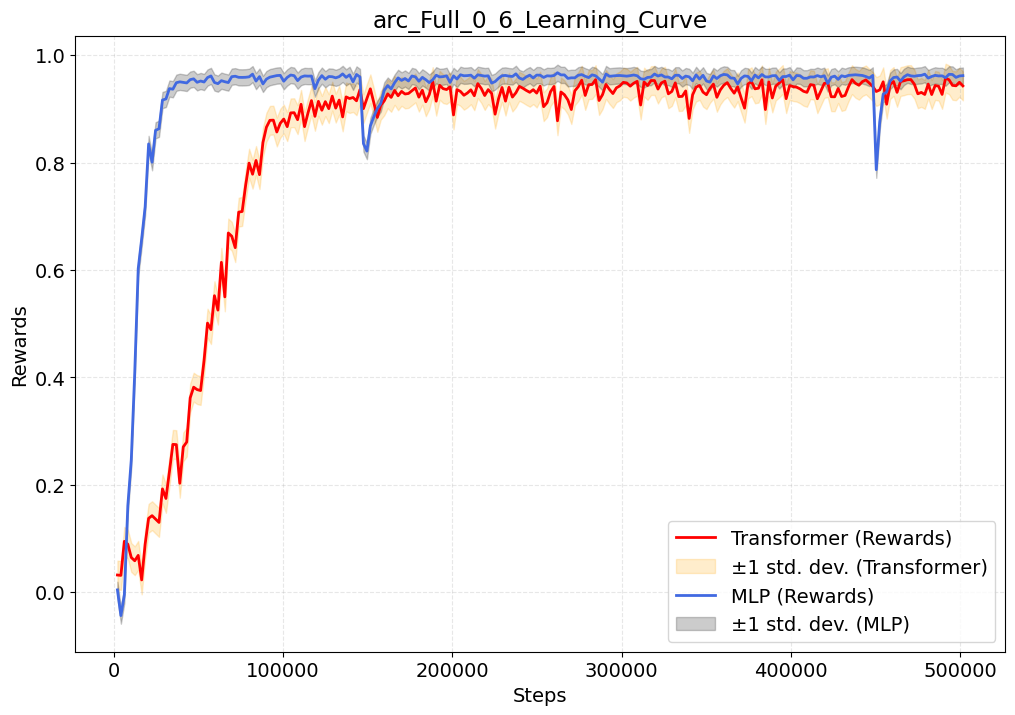

Processing Distribution Type: BASIC_SKILLS with Distractors: 0, and logdirs: ['logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_60_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_0_6_Learning_Curve.png


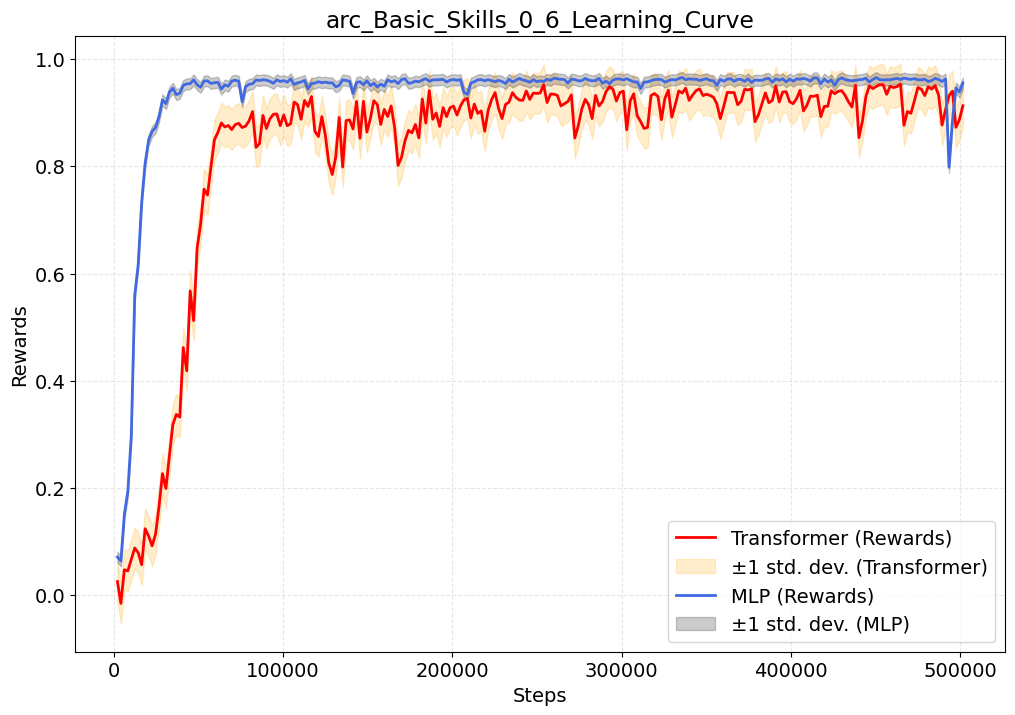

Processing Distribution Type: BASIC_SKILLS_EXCL with Distractors: 0, and logdirs: ['logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_0_8_BASIC_SKILLS_EXCL_60_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/minigrid_mlp_0_8_BASIC_SKILLS_EXCL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_Excl_0_6_Learning_Curve.png


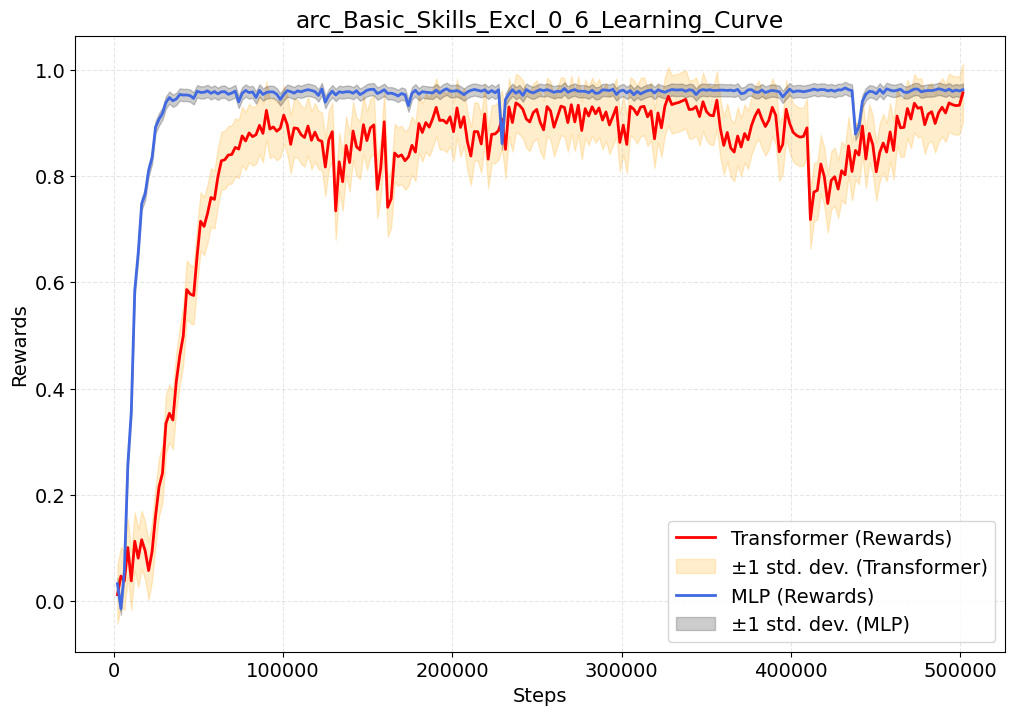

Processing Distribution Type: FULL with Distractors: 2, and logdirs: ['logs/ppo/simple/minigrid_trans_2_8_FULL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_FULL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_FULL_60_tensorboard', 'logs/ppo/minigrid_mlp_2_8_FULL_42_tensorboard', 'logs/ppo/minigrid_mlp_2_8_FULL_51_tensorboard', 'logs/ppo/minigrid_mlp_2_8_FULL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Full_2_6_Learning_Curve.png


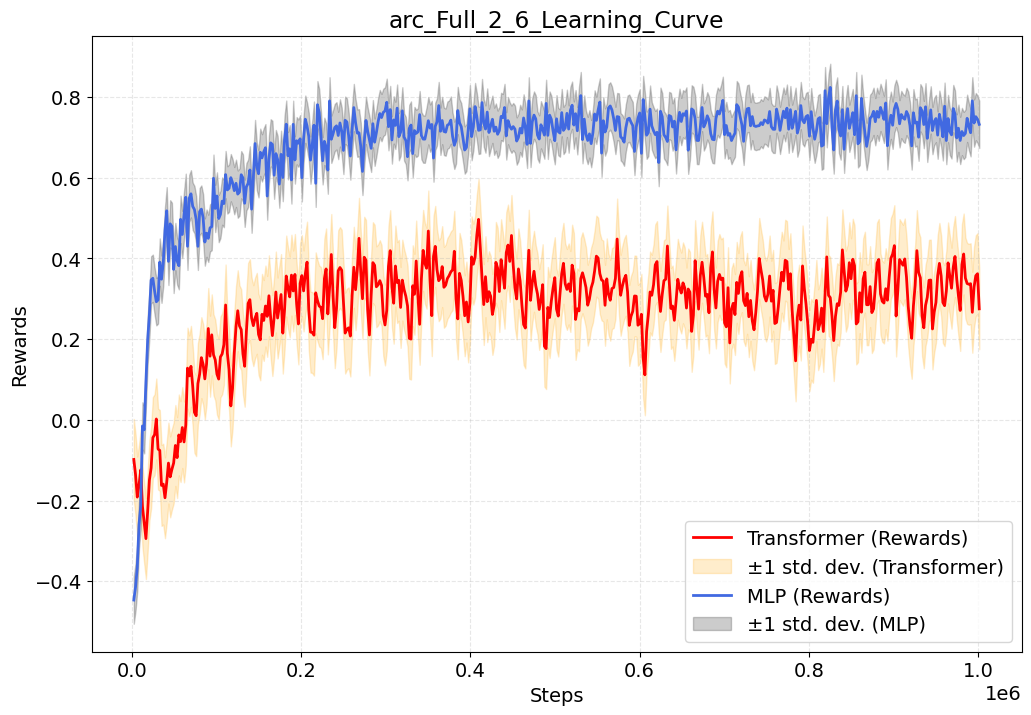

Processing Distribution Type: BASIC_SKILLS with Distractors: 2, and logdirs: ['logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_60_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_2_6_Learning_Curve.png


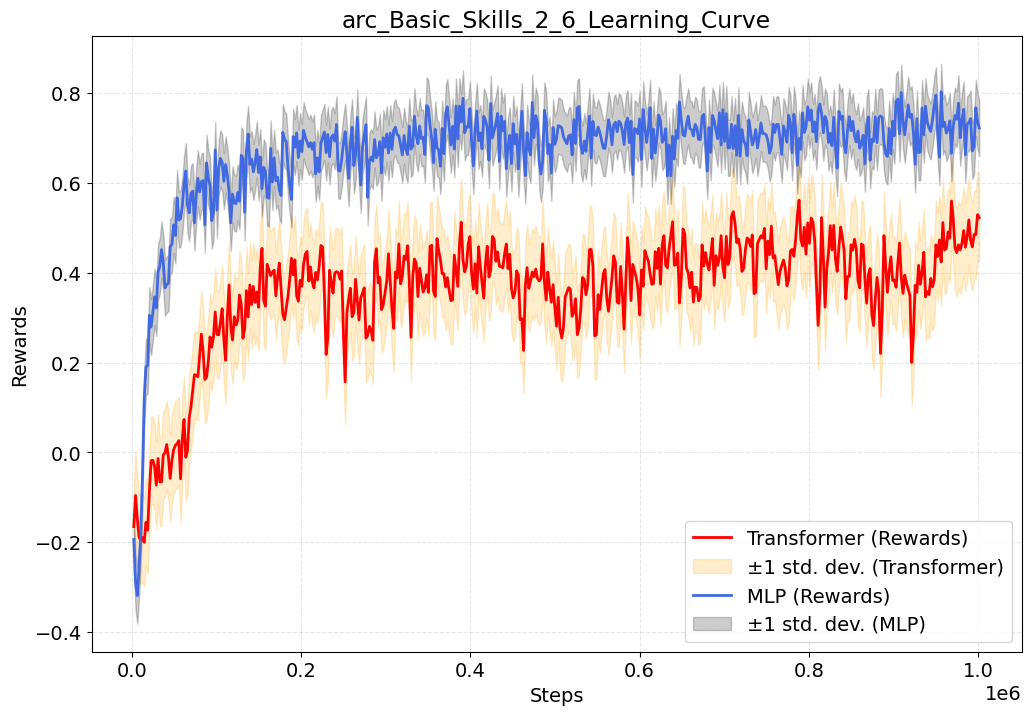

Processing Distribution Type: BASIC_SKILLS_EXCL with Distractors: 2, and logdirs: ['logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_2_8_BASIC_SKILLS_EXCL_60_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/minigrid_mlp_2_8_BASIC_SKILLS_EXCL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_Excl_2_6_Learning_Curve.png


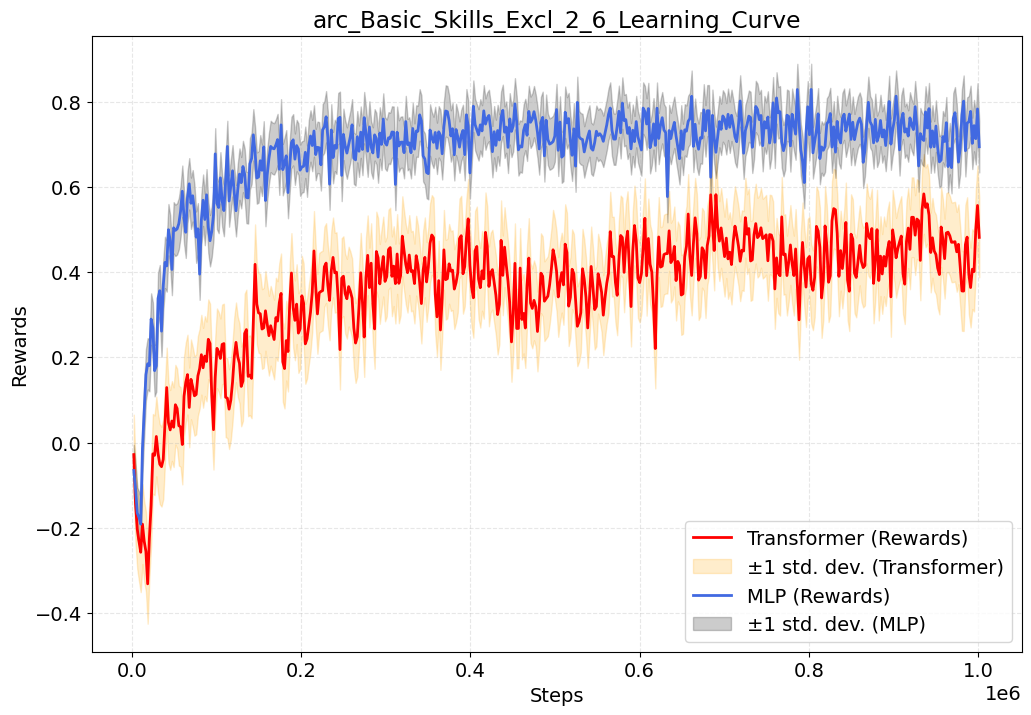

Processing Distribution Type: FULL with Distractors: 4, and logdirs: ['logs/ppo/simple/minigrid_trans_4_8_FULL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_FULL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_FULL_60_tensorboard', 'logs/ppo/minigrid_mlp_4_8_FULL_42_tensorboard', 'logs/ppo/minigrid_mlp_4_8_FULL_51_tensorboard', 'logs/ppo/minigrid_mlp_4_8_FULL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Full_4_6_Learning_Curve.png


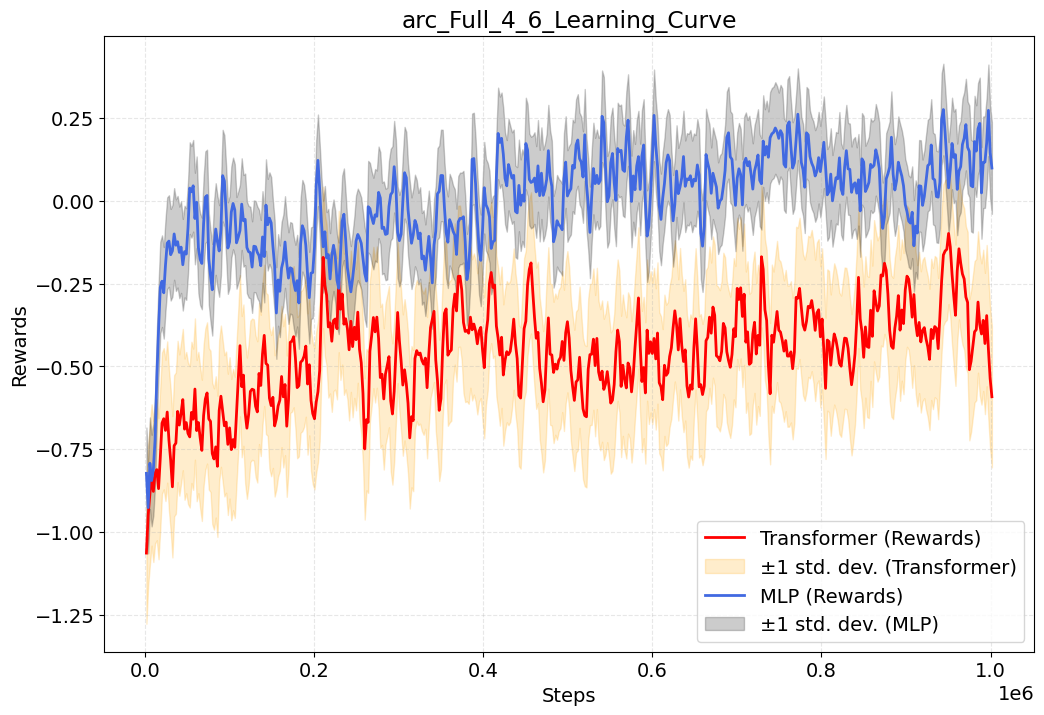

Processing Distribution Type: BASIC_SKILLS with Distractors: 4, and logdirs: ['logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_60_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_42_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_51_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_4_6_Learning_Curve.png


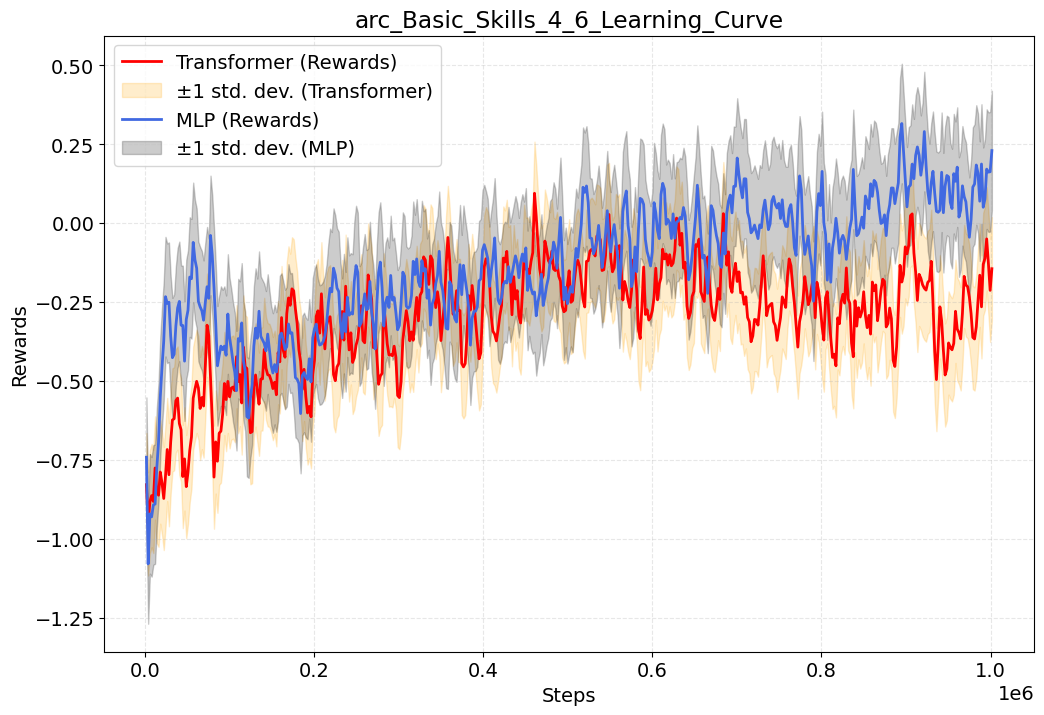

Processing Distribution Type: BASIC_SKILLS_EXCL with Distractors: 4, and logdirs: ['logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/simple/minigrid_trans_4_8_BASIC_SKILLS_EXCL_60_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_EXCL_42_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_EXCL_51_tensorboard', 'logs/ppo/minigrid_mlp_4_8_BASIC_SKILLS_EXCL_60_tensorboard']
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Loaded 3 runs for tag 'rollout/ep_rew_mean'
✅ Saved plot to arc_Basic_Skills_Excl_4_6_Learning_Curve.png


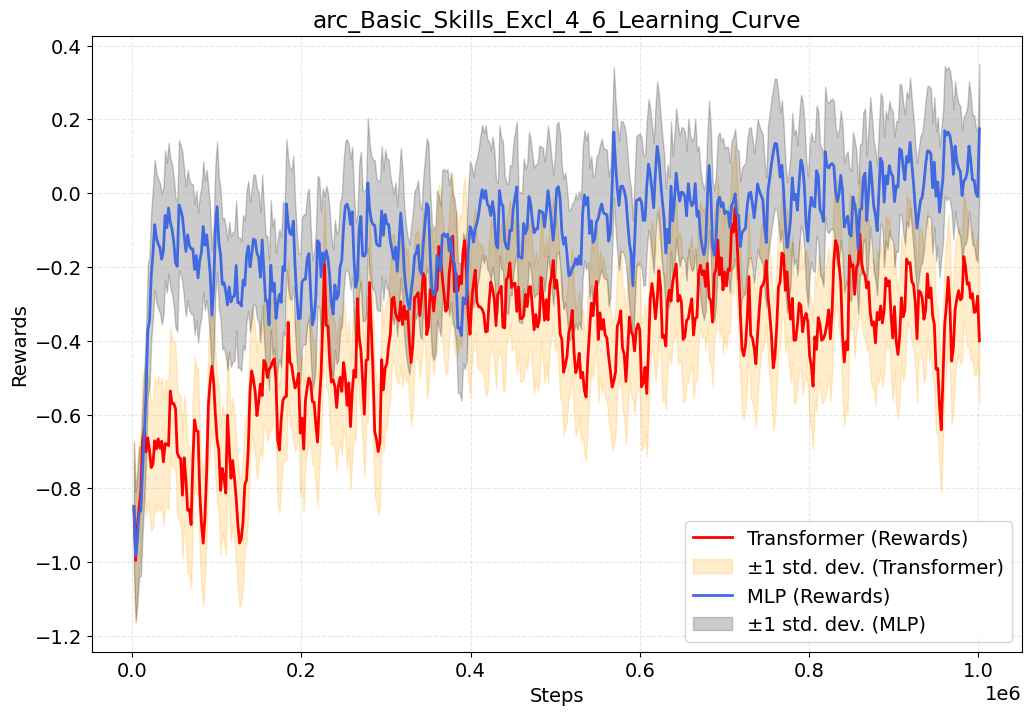

[{'Model Type': 'Transformer',
  'Distribution Type': 'FULL',
  '#Distractors': 0,
  'Episode Len': 36,
  'Mean': np.float64(0.832),
  'Standard Deviation': np.float64(0.027),
  'AUC': np.float64(416498.94)},
 {'Model Type': 'MLP',
  'Distribution Type': 'FULL',
  '#Distractors': 0,
  'Episode Len': 36,
  'Mean': np.float64(0.928),
  'Standard Deviation': np.float64(0.015),
  'AUC': np.float64(464817.713)},
 {'Model Type': 'Transformer',
  'Distribution Type': 'BASIC_SKILLS',
  '#Distractors': 0,
  'Episode Len': 36,
  'Mean': np.float64(0.838),
  'Standard Deviation': np.float64(0.038),
  'AUC': np.float64(419668.403)},
 {'Model Type': 'MLP',
  'Distribution Type': 'BASIC_SKILLS',
  '#Distractors': 0,
  'Episode Len': 36,
  'Mean': np.float64(0.935),
  'Standard Deviation': np.float64(0.01),
  'AUC': np.float64(467916.524)},
 {'Model Type': 'Transformer',
  'Distribution Type': 'BASIC_SKILLS_EXCL',
  '#Distractors': 0,
  'Episode Len': 36,
  'Mean': np.float64(0.819),
  'Standard Devi

In [5]:
import os
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tensorboard_data(logdir, tag="rollout/ep_rew_mean"):
    """
    Load scalar data from a TensorBoard event file.

    Parameters
    ----------
    logdir : str
        Path to the directory containing TensorBoard event files.
    tag : str
        Tag name to extract, e.g. "rollout/ep_rew_mean".

    Returns
    -------
    pd.DataFrame
        DataFrame with columns ['step', 'value'].
    """
    
    file_obj = find_files(logdir + "/", "*events.out.tfevents*")
    event_acc = EventAccumulator(file_obj[0])
    event_acc.Reload()
    if tag not in event_acc.Tags()['scalars']:
        raise ValueError(f"Tag '{tag}' not found in {logdir}")

    events = event_acc.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    df = pd.DataFrame({"step": steps, "value": values})
    df["logdir"] = os.path.basename(logdir.rstrip("/"))
    return df


def aggregate_runs(logdirs, tag="rollout/ep_rew_mean"):
    """
    Combine multiple runs (different seeds) and compute mean/std curves.

    Parameters
    ----------
    logdirs : list[str]
        List of paths to TensorBoard log directories.
    tag : str
        Tag name to extract.

    Returns
    -------
    (pd.DataFrame, pd.DataFrame)
        raw_df : concatenated raw data
        stats_df : DataFrame with mean/std/min/max across runs
    """
    runs = []
    for d in logdirs:
        df = load_tensorboard_data(d, tag)
        runs.append(df)

    print(f"✅ Loaded {len(runs)} runs for tag '{tag}'")
    
    # Merge by step using outer join
    merged = pd.concat(runs, ignore_index=True)

    # Compute statistics grouped by training step
    stats = (
        merged.groupby("step")["value"]
        .agg(["mean", "std", "min", "max", "count"])
        .reset_index()
    )

    return merged, stats


def plot_runs_and_average(raw_df, stats_df, save_path=None):
    """
    Plot all runs, average curve, and ±1 std. band.

    Parameters
    ----------
    raw_df : list
        Raw combined data from all seeds.
    stats_df : pd.DataFrame
        Mean/std aggregated statistics.
    tag : str
        Metric name (for title/labels).
    save_path : str | None
        Optional path to save plot image.
    """

    colors = [("red","orange"),("royalblue","black")]
    overall_std = [0.0, 0.0]
    
    plt.figure(figsize=(12, 8))
    
    for k in range(len(stats_df)):
        plt.plot(stats_df[k]["step"], stats_df[k]["mean"], color=colors[k][0], linewidth=2, label=f"{labels[k]} (Rewards)")
        overall_std[k] = (raw_df[k].groupby("logdir")['value'].agg('mean')).std()
        plt.fill_between(
			stats_df[k]["step"],
			stats_df[k]["mean"] - stats_df[k]['std'].mean(),
			stats_df[k]["mean"] + stats_df[k]['std'].mean(),
			color=colors[k][1],
			alpha=0.2,
			label=f"±1 std. dev. ({labels[k]})"
		)

    plt.title(save_path[:-4])
    plt.xlabel("Steps")
    plt.ylabel("Rewards")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)

    if save_path:
        plt.savefig(f"images/{save_path}", dpi=300, bbox_inches="tight")
        print(f"✅ Saved plot to {save_path}")

    plt.show()


def compute_auc(stats_df, raw_df=None):
    """
    Compute AUC (area under the curve) for the mean curve,
    and optionally for each individual run.
    """
    auc_stats = {}

    # Mean AUC across the averaged curve
    auc_mean = np.trapezoid(stats_df["mean"], stats_df["step"])
    auc_stats["mean_auc"] = auc_mean

    if raw_df is not None:
        auc_per_run = {}
        for run_name, df_run in raw_df.groupby("logdir"):
            auc_run = np.trapezoid(df_run["value"], df_run["step"])
            auc_per_run[run_name] = auc_run
        auc_stats["per_run_auc"] = auc_per_run
        auc_stats["mean_auc_of_runs"] = np.mean(list(auc_per_run.values()))
        auc_stats["std_auc_of_runs"] = np.std(list(auc_per_run.values()))
    else:
        auc_stats["per_run_auc"] = None

    return auc_stats



if __name__ == "__main__":

    dist_types = ("FULL", "BASIC_SKILLS", "BASIC_SKILLS_EXCL")
    algo = ["trans","mlp"]
    grid_size = 8
    distractors = (0,2,4)
    
    for d in distractors:
        for i in range(len(dist_types)):
            seeds = [42,51,60]
            raw_dfs = [None,None]
            stats_dfs = [None,None]
            auc_stats = list()

            logdirs = [f"logs/ppo/simple/minigrid_{algo[0]}_{d}_{grid_size}_{dist_types[i]}_{seed}_tensorboard" for seed in seeds] \
                    +	[f"logs/ppo/minigrid_{algo[1]}_{d}_{grid_size}_{dist_types[i]}_{seed}_tensorboard" for seed in seeds]
        
            print(f"Processing Distribution Type: {dist_types[i]} with Distractors: {d}, and logdirs: {logdirs}")
        
            for k in range(len(raw_dfs)):	raw_dfs[k], stats_dfs[k] = aggregate_runs(logdirs[k*3:(k+1)*3], tag="rollout/ep_rew_mean")

            plot_runs_and_average(raw_dfs, stats_dfs, save_path=f"arc_{dist_types[i].title()}_{d}_{grid_size - 2}_Learning_Curve.png")

            auc_stats = [compute_auc(stats_dfs[k], raw_dfs[k]) for k in range(len(raw_dfs))]
        
            for k in range(len(raw_dfs)):
                TRAINING_DATA_STATS.append({
                    "Model Type": labels[k],
                    "Distribution Type": dist_types[i],
                    "#Distractors": d,
                    "Episode Len": (1+d)*(6)**2, 
                    "Mean": round(stats_dfs[k]['mean'].mean(),3),
                    "Standard Deviation": round(stats_dfs[k]['std'].mean(),3),
                    "AUC": round(auc_stats[k]['mean_auc'],3),
                })

TRAINING_DATA_STATS

In [6]:
training_df = pd.DataFrame(TRAINING_DATA_STATS)
training_df.to_csv("data/training_data_stats.csv", index=False)

In [34]:
import pandas as pd
import numpy as np
from global_utils import DistType


data = []
summary = []
models = ["mlp","transformer"] * 9
dst_types = [0,0,1,1,2,2] * 3 
distractors = (0,0,0,0,0,0,2,2,2,2,2,2,4,4,4,4,4,4)

data_files  = ['mlp_FULL_0_aggregated_evaluation.csv',
            'trans_FULL_0_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_0_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_0_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_EXCL_0_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_EXCL_0_aggregated_evaluation.csv',
            'mlp_FULL_2_aggregated_evaluation.csv',
            'trans_FULL_2_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_2_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_2_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_EXCL_2_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_EXCL_2_aggregated_evaluation.csv',
            'mlp_FULL_4_aggregated_evaluation.csv',
            'trans_FULL_4_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_4_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_4_aggregated_evaluation.csv',
            'mlp_BASIC_SKILLS_EXCL_4_aggregated_evaluation.csv',
            'trans_BASIC_SKILLS_EXCL_4_aggregated_evaluation.csv']

for f in range(len(data_files)):
    data.append(pd.read_csv('data/' + data_files[f]))


if len(data_files) == len(distractors) == len(models) == len(data):

    for k in range(len(data)):
        data[k].attrs["model type".title()] = models[k]
        data[k].attrs["# distractors".title()] = distractors[k]
        data[k].attrs["distribution type".title()] = f"{DistType(dst_types[k]+1).name.lower()}"
        # data[k].attrs["mission desc".title()] = "goto green & ball object"
        data[k].attrs["avg reward".title()] = np.round(data[k]["mean_reward"].mean(),3)
        data[k].attrs["reward std".title()] = np.round(data[k]["mean_reward"].std(),3)
        data[k].attrs["success rate (%)".title()] = np.round(data[k]["success_rate"].mean() * 100,2)
        data[k].attrs["success rate std".title()] = np.round(data[k]["success_rate"].std(),3)
        data[k].attrs["avg episode length".title()] = np.round(data[k]["episode_len"].mean(),3)

        summary.append(data[k].attrs)

    summary = pd.DataFrame(summary)
    summary.to_excel("./data/evaluation_summary.xlsx", index=False)
    print("✅ Evaluation data saved successfully")
    
else: print("ALL DATA LISTS MUST BE OF THE SAME SIZE: data_files) == len(distractors) == len(models) == len(data")    

✅ Evaluation data saved successfully


In [48]:
# from PIL import Image

# # image_paths = ['images/arc_Full_0_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_0_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_Excl_0_6_Learning_Curve.png'
# # ,'images/arc_Full_2_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_2_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_Excl_2_6_Learning_Curve.png'
# # ,'images/arc_Full_4_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_4_6_Learning_Curve.png'
# # ,'images/arc_Basic_Skills_Excl_4_6_Learning_Curve.png']

# image_paths = ['images/evaluation/FULL_0_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_0_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_EXCL_0_aggregated_rewards_success.png'
# ,'images/evaluation/FULL_2_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_2_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_EXCL_2_aggregated_rewards_success.png'
# ,'images/evaluation/FULL_4_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_4_aggregated_rewards_success.png'
# ,'images/evaluation/BASIC_SKILLS_EXCL_4_aggregated_rewards_success.png'
# ]

# # Load images
# images = [Image.open(p) for p in image_paths]

# # (Optional) Resize to a uniform size if needed
# w, h = images[0].size   # assumes all are identical size
# images = [img.resize((w, h)) for img in images]

# # Create blank canvas for 3x3 grid
# grid_w = 3 * w
# grid_h = 3 * h
# grid_img = Image.new("RGB", (grid_w, grid_h), color=(255, 255, 255))

# # Paste images row-wise
# for idx, img in enumerate(images):
#     row = idx // 3
#     col = idx % 3
#     grid_img.paste(img, (col * w, row * h))

# # Save final 3x3 grid
# grid_img.save("images/evaluation/joined_evaluation_graphs.png")
# grid_img.show()